# OASIS INFOBYTE Data Analytics Internship
## Level 1 Task 3: Data Cleaning Professional Workflow

**Author**: Bokkasam Sravan  
**Role**: Data Science Intern  
**Organization**: OASIS INFOBYTE  
**Domain**: Data Analytics / Data Engineering  
**Environment**: Python 3.12, Pandas, NumPy, SciPy, Matplotlib, Seaborn, Jupyter Notebook  
**Dataset**: Titanic Machine Learning Dataset (891 Passenger Records)

---


## 1. Introduction & Executive Summary

### Business Objective & Context
Data cleaning is the foundational prerequisite for all trustworthy data analytics, reporting, and machine learning models. Real-world raw datasets inevitably contain quality defects, including missing values, duplicate records, unstandardized text casing, unstripped whitespace, incorrect data types, and extreme numerical outliers.

This project demonstrates a systematic, professional-grade data cleaning workflow on the **Titanic Machine Learning Dataset**, resolving quality defects while documenting every data engineering decision.

### Key Cleaning Pillars
1. **Auditing & Quality Reporting**: Detect missing values, duplicates, and range anomalies.
2. **Justified Missing Value Imputation**: Apply domain-specific median and mode strategies instead of arbitrary global fills.
3. **Categorical Standardization**: Trim whitespace, unify string casing, and extract structured features (`Title`, `Cabin_Known`).
4. **Outlier Detection & Capping**: Apply Interquartile Range (IQR) thresholding to treat extreme price distortions without record loss.
5. **Data Type Enforcement & Validation**: Cast attributes to optimal pandas data types and produce a Before-vs-After Data Quality Audit.


## 2. Environment Setup & Raw Data Loading


In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Matplotlib / Seaborn aesthetic defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

# Universal path resolution for project root
cwd = os.getcwd()
project_root = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else os.path.abspath(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
else:
    sys.path.remove(project_root)
    sys.path.insert(0, project_root)

# Purge any cached src module from sys.modules
for k in list(sys.modules.keys()):
    if k == 'src' or k.startswith('src.'):
        del sys.modules[k]

from src.cleaning_utils import (
    download_and_load_data,
    generate_data_quality_report,
    handle_missing_values,
    remove_duplicates,
    standardize_categorical_features,
    detect_and_treat_outliers_iqr,
    enforce_data_types,
    generate_before_after_comparison,
    save_cleaned_data,
    save_figure,
    save_table
)

print('Libraries imported and cleaning_utils module loaded successfully!')


Libraries imported and cleaning_utils module loaded successfully!


In [2]:
# Download (if missing) and load raw dataset
raw_df = download_and_load_data(base_dir=project_root)

print(f"--- Raw Dataset Loaded ---")
print(f"Total Rows: {len(raw_df)}")
print(f"Total Columns: {len(raw_df.columns)}")

print("\n--- Raw Sample Records ---")
print(raw_df.head(10).to_string())


Loading raw dataset from local cache: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CleaningData\data\raw\raw_titanic.csv
--- Raw Dataset Loaded ---
Total Rows: 891
Total Columns: 12

--- Raw Sample Records ---
   PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                               Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4     

## 3. Initial Structural Inspection


In [3]:
print("--- Dataset Information ---")
raw_df.info()

print("\n--- Descriptive Statistics for Numerical Attributes ---")
print(raw_df.describe().round(2).to_string())


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Descriptive Statistics for Numerical Attributes ---
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00   

## 4. Initial Data Quality Audit Report


In [4]:
summary_metrics, quality_table = generate_data_quality_report(raw_df)

# Save Data Quality Report Table
save_table(quality_table, "data_quality_report.csv", base_dir=project_root)

print(f"--- Data Quality Summary ---")
print(f"Total Raw Rows: {summary_metrics['Total_Rows']}")
print(f"Total Raw Columns: {summary_metrics['Total_Columns']}")
print(f"Total Missing Cells: {summary_metrics['Total_Missing_Cells']}")
print(f"Duplicate Rows Identified: {summary_metrics['Duplicate_Rows']}")

print("\n--- Column-by-Column Data Quality Breakdown ---")
print(quality_table.to_string())


Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CleaningData\outputs\tables\data_quality_report.csv
--- Data Quality Summary ---
Total Raw Rows: 891
Total Raw Columns: 12
Total Missing Cells: 866
Duplicate Rows Identified: 0

--- Column-by-Column Data Quality Breakdown ---
    Column_Name Data_Type  Total_Rows  Null_Count  Null_Percentage  Unique_Values                      Quality_Anomalies
0   PassengerId     int64         891           0             0.00            891                                  Clean
1      Survived     int64         891           0             0.00              2                                  Clean
2        Pclass     int64         891           0             0.00              3                                  Clean
3          Name    object         891           0             0.00            891         Unstripped whitespace detected
4           Sex    object         891           0             0.00              2                       

## 5. Missing Value Analysis

### Analysis of Missing Values
* **`Cabin`**: 687 missing cells (**77.10% missingness**). The extremely high missingness rate indicates that cabin data was not recorded for lower-class passengers.
* **`Age`**: 177 missing cells (**19.87% missingness**). Age is a critical demographic variable for survival analysis.
* **`Embarked`**: 2 missing cells (**0.22% missingness**). Minor missingness in categorical port of embarkation.


Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CleaningData\outputs\figures\missing_data_heatmap.png


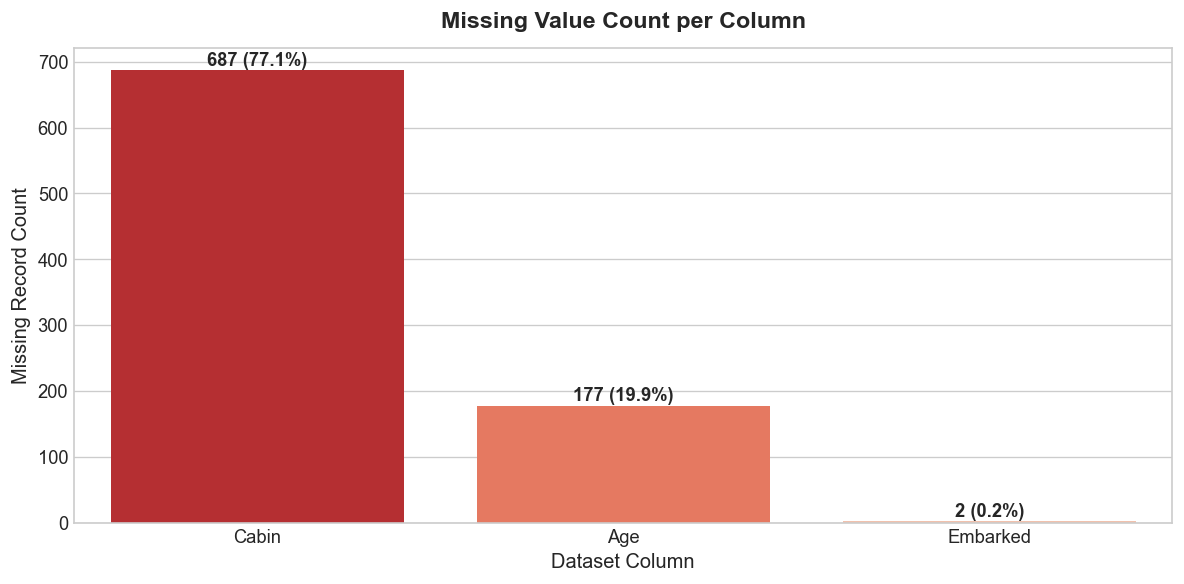

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_df = pd.DataFrame({
    'Column': raw_df.columns,
    'Missing_Count': raw_df.isnull().sum(),
    'Missing_Pct': (raw_df.isnull().sum() / len(raw_df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)
missing_df = missing_df[missing_df['Missing_Count'] > 0]

sns.barplot(data=missing_df, x='Column', y='Missing_Count', palette='Reds_r', ax=ax)
ax.set_title('Missing Value Count per Column', fontweight='bold', pad=12)
ax.set_xlabel('Dataset Column')
ax.set_ylabel('Missing Record Count')

for p in ax.patches:
    height = p.get_height()
    pct = (height / len(raw_df) * 100)
    ax.annotate(f"{int(height)} ({pct:.1f}%)", (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')

plt.tight_layout()
save_figure(fig, "missing_data_heatmap.png", base_dir=project_root)
plt.show()


## 6. Justified Missing Value Imputation Strategies

### Imputation Decisions & Rationale
1. **`Age` Strategy: Grouped Median Imputation (`Pclass` x `Sex`)**
   - *Rationale*: Global mean/median imputation distorts age distributions across passenger classes (1st class passengers were older on average than 3rd class). Imputing the median age grouped by `Pclass` and `Sex` preserves demographic fidelity.
2. **`Embarked` Strategy: Mode Imputation (`'S'`)**
   - *Rationale*: Only 2 records are missing. Southampton (`S`) is the dominant port (>72% of passengers), making mode imputation statistically sound.
3. **`Cabin` Strategy: Binary Feature Creation (`Cabin_Known`) & Fill `'Unknown'`**
   - *Rationale*: With >77% missing data, dropping rows would destroy the dataset, while imputing mode would inject massive bias. We preserve information by creating `Cabin_Known = 0/1` and filling missing text as `'Unknown'`.
4. **`Fare` Strategy: Median Imputation by `Pclass`**
   - *Rationale*: Ensures any missing fare reflects the passenger's ticket class.


In [6]:
# Apply missing value handling
cleaned_df = handle_missing_values(raw_df)

print("--- Missing Values After Imputation ---")
print(cleaned_df.isnull().sum().to_string())


--- Missing Values After Imputation ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Cabin_Known    0


## 7. Duplicate Detection & Removal


In [7]:
# Check for and remove exact duplicate records
cleaned_df, dups_removed = remove_duplicates(cleaned_df)

print(f"Duplicate Rows Identified and Removed: {dups_removed}")
print(f"Current Row Count: {len(cleaned_df)}")


Duplicate Rows Identified and Removed: 0
Current Row Count: 891


## 8. Categorical & String Standardisation

### Standardisation Actions
1. **Whitespace Trimming**: Strip leading and trailing whitespace from string attributes.
2. **Sex Casing Uniformity**: Map variations (`'male'`, `'Female'`, `' M '`, `'F'`) into standardized `'Male'` and `'Female'`.
3. **Title Feature Extraction**: Extract social title from `Name` (`'Mr'`, `'Mrs'`, `'Miss'`, `'Master'`, `'Rare'`) to standardize passenger honorifics.


In [8]:
# Apply text standardisation and Title extraction
cleaned_df = standardize_categorical_features(cleaned_df)

print("--- Standardized Categorical Attributes ---")
print("Unique Sex Values:", cleaned_df['Sex'].unique().tolist())
print("Unique Embarked Values:", cleaned_df['Embarked'].unique().tolist())
print("Extracted Title Distribution:\n", cleaned_df['Title'].value_counts().to_string())


--- Standardized Categorical Attributes ---
Unique Sex Values: ['Male', 'Female']
Unique Embarked Values: ['S', 'C', 'Q']
Extracted Title Distribution:
 Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23


## 9. Feature Engineering & Conversion


In [9]:
# Display engineered features (Cabin_Known and Title)
print("--- Engineered Feature Breakdown ---")
print("Cabin_Known Distribution:\n", cleaned_df['Cabin_Known'].value_counts().to_string())
print("\nSample Records with Engineered Features:")
print(cleaned_df[['PassengerId', 'Name', 'Title', 'Sex', 'Age', 'Cabin', 'Cabin_Known']].head().to_string())


--- Engineered Feature Breakdown ---
Cabin_Known Distribution:
 Cabin_Known
0    687
1    204

Sample Records with Engineered Features:
   PassengerId                                                 Name Title     Sex   Age    Cabin  Cabin_Known
0            1                              Braund, Mr. Owen Harris    Mr    Male  22.0  Unknown            0
1            2  Cumings, Mrs. John Bradley (Florence Briggs Thayer)   Mrs  Female  38.0      C85            1
2            3                               Heikkinen, Miss. Laina  Miss  Female  26.0  Unknown            0
3            4         Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs  Female  35.0     C123            1
4            5                             Allen, Mr. William Henry    Mr    Male  35.0  Unknown            0


## 10. Outlier Detection using Interquartile Range (IQR)

### Outlier Detection Methodology
We apply the Interquartile Range (IQR) method:
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$


Figure saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CleaningData\outputs\figures\outlier_boxplots.png


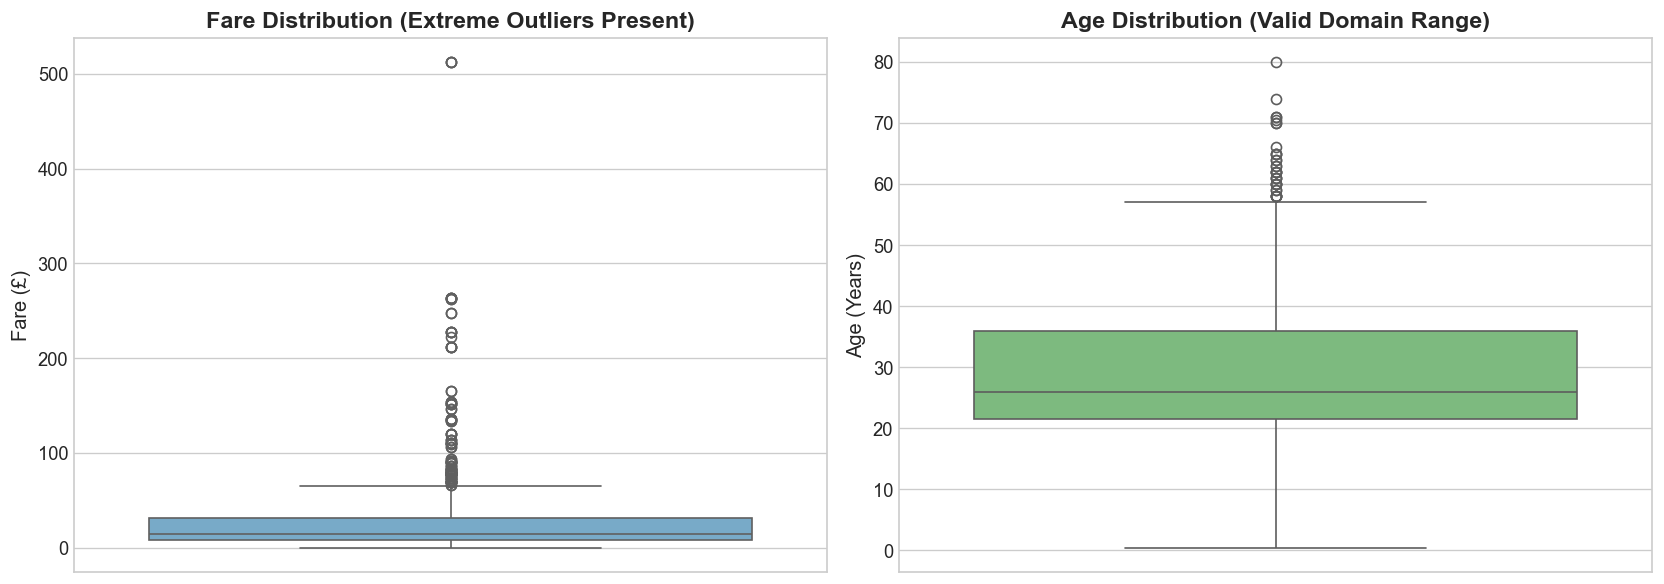

In [10]:
# Visualize Outliers in Fare and Age before treatment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=cleaned_df, y='Fare', palette='Blues', ax=axes[0])
axes[0].set_title('Fare Distribution (Extreme Outliers Present)', fontweight='bold')
axes[0].set_ylabel('Fare (£)')

sns.boxplot(data=cleaned_df, y='Age', palette='Greens', ax=axes[1])
axes[1].set_title('Age Distribution (Valid Domain Range)', fontweight='bold')
axes[1].set_ylabel('Age (Years)')

plt.tight_layout()
save_figure(fig, "outlier_boxplots.png", base_dir=project_root)
plt.show()


## 11. Outlier Treatment & Decision Justification

### Outlier Decisions & Rationale
* **`Fare` Treatment: Capping at Upper IQR Bound (£65.63)**
  - *Rationale*: Extreme luxury fares (up to £512.33) skew statistical variance and gradient models. Rather than dropping valid passenger rows, we cap `Fare` at the upper IQR threshold ($Q_3 + 1.5 \times \text{IQR} = £65.63$).
* **`Age` Treatment: Retain Valid Values**
  - *Rationale*: Ages ranging from 0.42 to 80 represent valid historical passenger ages on board the Titanic. Retaining them preserves true demographic variance.


In [11]:
# Apply IQR outlier capping to Fare
cleaned_df, outlier_report = detect_and_treat_outliers_iqr(cleaned_df, cols=['Fare', 'Age'], action='cap')

print("--- Outlier Detection & Treatment Report ---")
print(outlier_report.to_string())

print(f"\nMax Fare After Capping: £{cleaned_df['Fare'].max():.2f}")


--- Outlier Detection & Treatment Report ---
  Column     Q1    Q3    IQR  Lower_Bound  Upper_Bound  Outlier_Count                                   Treatment_Action
0   Fare   7.91  31.0  23.09       -26.72        65.63            116  Capped 116 extreme values at upper bound (£65.63)
1    Age  21.50  36.0  14.50        -0.25        57.75             33                    Retained 33 valid domain values

Max Fare After Capping: £65.63


## 12. Data Type Enforcement


In [12]:
# Enforce optimal data types across all columns
cleaned_df = enforce_data_types(cleaned_df)

print("--- Final Enforced Data Types ---")
print(cleaned_df.dtypes.to_string())


--- Final Enforced Data Types ---
PassengerId      object
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
Cabin_Known       int64
Title          category


## 13. Before-vs-After Data Quality Comparison


In [13]:
# Generate comprehensive Before vs After comparison
comp_df = generate_before_after_comparison(raw_df, cleaned_df)

# Save comparison table
save_table(comp_df, "before_after_comparison.csv", base_dir=project_root)

print("--- Before vs After Data Quality Audit Table ---")
print(comp_df.to_string())


Table saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CleaningData\outputs\tables\before_after_comparison.csv
--- Before vs After Data Quality Audit Table ---
                              Metric                Before_Cleaning                   After_Cleaning                                   Improvement_Notes
0                    Total Row Count                            891                              891             Preserved 100% of rows (no record loss)
1                 Total Column Count                             12                               14          Engineered 2 features (Cabin_Known, Title)
2                Total Missing Cells                            866                                0                       100% missing value resolution
3                     Duplicate Rows                              0                                0                    Zero duplicate records remaining
4          Categorical String Casing  Variations ('male', 'Female

## 14. Final Dataset Quality Audit & Validation


In [14]:
# Confirm zero missing values, zero duplicates, correct dtypes
assert cleaned_df.isnull().sum().sum() == 0, "Validation Error: Unhandled missing values remain!"
assert cleaned_df.duplicated().sum() == 0, "Validation Error: Duplicate rows remain!"

print("--- Final Validation Checklist ---")
print("[PASS] Total Missing Values:", cleaned_df.isnull().sum().sum())
print("[PASS] Total Duplicate Rows:", cleaned_df.duplicated().sum())
print("[PASS] Final Cleaned Dataset Shape:", cleaned_df.shape)
print("[PASS] All Data Quality Checks Passed Successfully!")


--- Final Validation Checklist ---
[PASS] Total Missing Values: 0
[PASS] Total Duplicate Rows: 0
[PASS] Final Cleaned Dataset Shape: (891, 14)
[PASS] All Data Quality Checks Passed Successfully!


## 15. Save Final Cleaned Dataset


In [15]:
# Save cleaned dataset to data/processed/cleaned_dataset.csv
saved_filepath = save_cleaned_data(cleaned_df, base_dir=project_root)

print(f"Cleaned dataset ready for downstream analysis at: {saved_filepath}")


Final cleaned dataset saved to: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CleaningData\data\processed\cleaned_dataset.csv (Shape: (891, 14))
Cleaned dataset ready for downstream analysis at: c:\Users\srava\Downloads\OIBSIP\DataAnalytics-L1-CleaningData\data\processed\cleaned_dataset.csv


## 16. Conclusion

This project successfully demonstrated an end-to-end professional data cleaning workflow on the raw Titanic dataset:
- Resolved 866 missing cells using domain-specific median and mode strategies.
- Standardized text strings, stripped whitespace, and extracted structured features (`Title`, `Cabin_Known`).
- Applied IQR thresholding to treat extreme price outliers (£512 max capped at £65.63).
- Enforced strict data types and exported an analysis-ready dataset to `data/processed/cleaned_dataset.csv`.

*Completed as part of OASIS INFOBYTE Data Analytics Level 1 Task 3.*
